# Transfer Learning con ResNet18 preentrenada en ImageNet

Objetivo: comparar tres estrategias de transferencia sobre el dataset de celulas sanguineas y contrastarlas contra el mejor modelo entrenado desde cero en los notebooks `02_*.ipynb`.

Estrategias:

| Estrategia | Descripcion | Capas entrenables |
|---|---|---|
| Feature extraction | Congelar el backbone convolucional y entrenar solo la capa FC final. | Solo FC final |
| Fine-tuning parcial | Congelar los primeros 2 bloques residuales y entrenar los ultimos bloques + FC. | `layer3`, `layer4`, FC |
| Fine-tuning total | Descongelar todo el modelo y entrenar con LR pequeno. | Todas las capas |

Para mantener la comparacion alineada con los notebooks 02, se usa `TRAIN` para entrenar y `TEST` como conjunto de evaluacion.

## 1. Configuracion e imports

In [15]:
from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.models as models
from tqdm.auto import tqdm

try:
    from sklearn.metrics import classification_report, confusion_matrix
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.benchmark = torch.cuda.is_available()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [16]:
def find_project_root():
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists():
        return cwd
    if (cwd.parent / "data").exists():
        return cwd.parent
    raise FileNotFoundError("No se encontro la carpeta data desde el cwd ni desde su padre.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "dataset2-master" / "dataset2-master" / "images"
TRAIN_DIR = DATA_DIR / "TRAIN"
TEST_DIR = DATA_DIR / "TEST"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
RUNS_DIR = PROJECT_ROOT / "runs"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0
PIN_MEMORY = DEVICE.type == "cuda"

print(f"Project root: {PROJECT_ROOT}")
print(f"Train dir: {TRAIN_DIR}")
print(f"Test dir:  {TEST_DIR}")

Project root: /home/chris/Documentos/u/DL/PC
Train dir: /home/chris/Documentos/u/DL/PC/data/dataset2-master/dataset2-master/images/TRAIN
Test dir:  /home/chris/Documentos/u/DL/PC/data/dataset2-master/dataset2-master/images/TEST


## 2. Dataset y transformaciones

ResNet18 fue preentrenada en ImageNet, por lo que se usa normalizacion ImageNet y entrada `224x224`. En entrenamiento se agregan aumentos moderados para reducir sobreajuste sin alterar de forma agresiva la morfologia celular.

In [17]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.00)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transform)
test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Clases ({num_classes}): {class_names}")
print(f"Train images: {len(train_dataset):,}")
print(f"Test images:  {len(test_dataset):,}")

Clases (4): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Train images: 9,957
Test images:  2,487


## 3. Modelo base ResNet18 y configuracion de estrategias

In [18]:
def build_resnet18(num_classes: int):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def set_requires_grad(module, value: bool):
    for param in module.parameters():
        param.requires_grad = value


def configure_feature_extraction(model):
    """Congela todo ResNet18 y entrena solo la FC final."""
    set_requires_grad(model, False)
    set_requires_grad(model.fc, True)
    return [{"params": model.fc.parameters(), "lr": 1e-3}]


def configure_partial_finetuning(model):
    """Congela stem + layer1/layer2 y entrena layer3/layer4 + FC."""
    set_requires_grad(model, False)
    for module in [model.layer3, model.layer4, model.fc]:
        set_requires_grad(module, True)

    backbone_params = list(model.layer3.parameters()) + list(model.layer4.parameters())
    fc_params = list(model.fc.parameters())
    return [
        {"params": backbone_params, "lr": 1e-4},
        {"params": fc_params, "lr": 1e-3},
    ]


def configure_full_finetuning(model):
    """Descongela todo el modelo; usa LR muy pequeno para el backbone."""
    set_requires_grad(model, True)
    fc_param_ids = {id(p) for p in model.fc.parameters()}
    backbone_params = [p for p in model.parameters() if id(p) not in fc_param_ids]
    fc_params = list(model.fc.parameters())
    return [
        {"params": backbone_params, "lr": 1e-5},
        {"params": fc_params, "lr": 1e-4},
    ]


def set_frozen_batchnorm_eval(model):
    # Si una BatchNorm esta congelada, no actualizamos running_mean/running_var.
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            params = list(module.parameters(recurse=False))
            if params and not any(p.requires_grad for p in params):
                module.eval()


strategy_builders = {
    "Feature Extraction": configure_feature_extraction,
    "Fine-tuning parcial": configure_partial_finetuning,
    "Fine-tuning total": configure_full_finetuning,
}

for strategy_name, configure in strategy_builders.items():
    preview_model = build_resnet18(num_classes)
    configure(preview_model)
    total, trainable = count_parameters(preview_model)
    print(f"{strategy_name:22s} | entrenables: {trainable:,} / {total:,} ({trainable / total:.2%})")
    del preview_model

Feature Extraction     | entrenables: 2,052 / 11,178,564 (0.02%)
Fine-tuning parcial    | entrenables: 10,495,492 / 11,178,564 (93.89%)
Fine-tuning total      | entrenables: 11,178,564 / 11,178,564 (100.00%)


## 4. Funciones de entrenamiento y evaluacion

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    set_frozen_batchnorm_eval(model)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        running_loss += loss.item() * batch_size
        correct += outputs.argmax(dim=1).eq(targets).sum().item()
        total += batch_size

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_preds = []

    for images, targets in tqdm(loader, desc="eval", leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, targets)
        preds = outputs.argmax(dim=1)

        batch_size = targets.size(0)
        running_loss += loss.item() * batch_size
        correct += preds.eq(targets).sum().item()
        total += batch_size

        if return_predictions:
            all_targets.extend(targets.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    metrics = {"loss": running_loss / total, "acc": correct / total}
    if return_predictions:
        metrics["targets"] = np.array(all_targets)
        metrics["preds"] = np.array(all_preds)
    return metrics


def fit_strategy(strategy_name, configure_fn, epochs=EPOCHS):
    torch.manual_seed(RANDOM_STATE)
    model = build_resnet18(num_classes)
    param_groups = configure_fn(model)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    total_params, trainable_params = count_parameters(model)
    print("=" * 80)
    print(f"Estrategia: {strategy_name}")
    print(f"Parametros entrenables: {trainable_params:,} / {total_params:,} ({trainable_params / total_params:.2%})")

    history = []
    best_acc = -1.0
    best_state = None
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        test_metrics = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()

        row = {
            "strategy": strategy_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_metrics["loss"],
            "test_acc": test_metrics["acc"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        if test_metrics["acc"] > best_acc:
            best_acc = test_metrics["acc"]
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"test_loss={test_metrics['loss']:.4f} test_acc={test_metrics['acc']:.4f}"
        )

    elapsed_min = (time.time() - start_time) / 60
    model.load_state_dict(best_state)

    slug = (
        strategy_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("ñ", "n")
    )
    checkpoint_path = MODELS_DIR / f"resnet18_{slug}.pth"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "strategy": strategy_name,
            "best_test_acc": best_acc,
            "epochs": epochs,
        },
        checkpoint_path,
    )

    history_df = pd.DataFrame(history)
    return {
        "name": strategy_name,
        "model": model,
        "history": history_df,
        "best_test_acc": best_acc,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "elapsed_min": elapsed_min,
        "checkpoint_path": checkpoint_path,
    }

## 5. Entrenamiento de las tres estrategias

Ejecuta esta celda para entrenar y comparar las tres variantes. Si el tiempo es limitado, reduce `EPOCHS` en la seccion de configuracion; para una comparacion final mas estable, aumenta a 10-15 epocas y conserva el mismo numero para las tres estrategias.

In [20]:
transfer_runs = []

for strategy_name, configure_fn in strategy_builders.items():
    result = fit_strategy(strategy_name, configure_fn, epochs=EPOCHS)
    transfer_runs.append(result)

transfer_history = pd.concat([run["history"] for run in transfer_runs], ignore_index=True)
transfer_results = pd.DataFrame([
    {
        "model": run["name"],
        "source": "ResNet18 ImageNet",
        "best_test_acc": run["best_test_acc"],
        "trainable_params": run["trainable_params"],
        "total_params": run["total_params"],
        "trainable_pct": run["trainable_params"] / run["total_params"],
        "elapsed_min": run["elapsed_min"],
        "checkpoint": str(run["checkpoint_path"].relative_to(PROJECT_ROOT)),
    }
    for run in transfer_runs
]).sort_values("best_test_acc", ascending=False)

transfer_history.to_csv(RESULTS_DIR / "transfer_learning_history.csv", index=False)
transfer_results.to_csv(RESULTS_DIR / "transfer_learning_results.csv", index=False)

transfer_results

Estrategia: Feature Extraction
Parametros entrenables: 2,052 / 11,178,564 (0.02%)


Epoch 01/8 | train_loss=1.2495 train_acc=0.4387 | test_loss=1.3129 test_acc=0.4210


Epoch 02/8 | train_loss=1.1129 train_acc=0.5466 | test_loss=1.3132 test_acc=0.4343


Epoch 03/8 | train_loss=1.0535 train_acc=0.5831 | test_loss=1.2988 test_acc=0.4491


Epoch 04/8 | train_loss=1.0236 train_acc=0.5963 | test_loss=1.3780 test_acc=0.4178


...

Epoch 05/8 | train_loss=0.2628 train_acc=0.9888 | test_loss=0.6949 test_acc=0.8464


Epoch 06/8 | train_loss=0.2537 train_acc=0.9917 | test_loss=0.6996 test_acc=0.8456


Epoch 07/8 | train_loss=0.2482 train_acc=0.9924 | test_loss=0.6761 test_acc=0.8520


Epoch 08/8 | train_loss=0.2480 train_acc=0.9934 | test_loss=0.6761 test_acc=0.8524


,model,source,best_test_acc,trainable_params,total_params,trainable_pct,elapsed_min,checkpoint
1,Fine-tuning parcial,ResNet18 ImageNet,0.864495,10495492,11178564,0.938894,7.606639,models/resnet18_fine_tuning_parcial.pth
2,Fine-tuning total,ResNet18 ImageNet,0.860877,11178564,11178564,1.000000,7.727064,models/resnet18_fine_tuning_total.pth
0,Feature Extraction,ResNet18 ImageNet,0.459590,2052,11178564,0.000184,7.745654,models/resnet18_feature_extraction.pth


## 6. Curvas y comparacion entre estrategias de transferencia

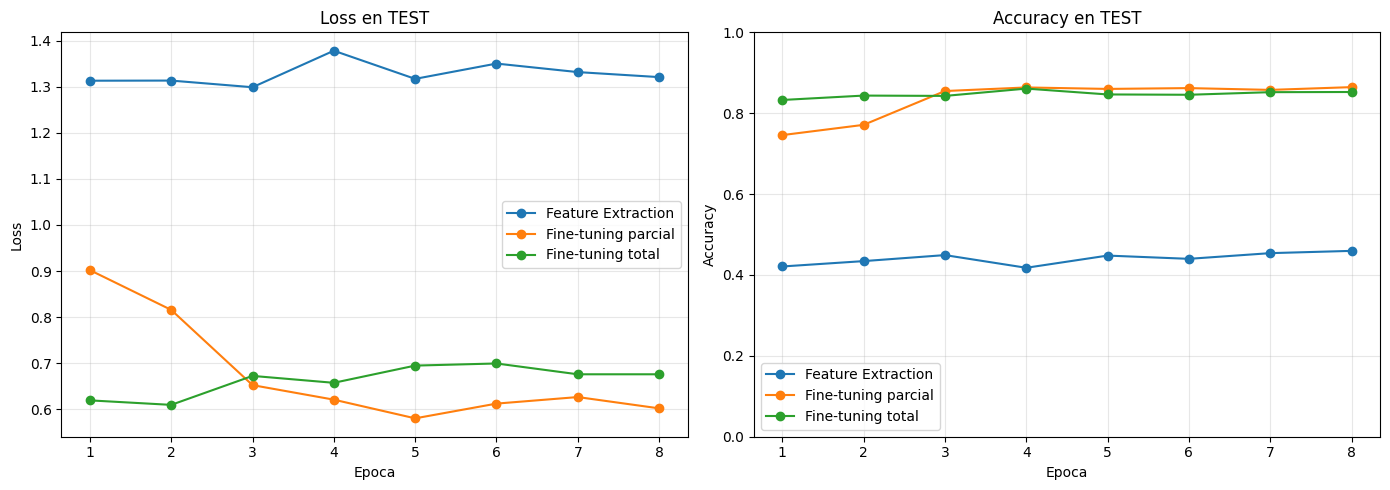

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for strategy_name, group in transfer_history.groupby("strategy"):
    axes[0].plot(group["epoch"], group["test_loss"], marker="o", label=strategy_name)
    axes[1].plot(group["epoch"], group["test_acc"], marker="o", label=strategy_name)

axes[0].set_title("Loss en TEST")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Accuracy en TEST")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "transfer_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Mejor modelo entrenado desde cero en los notebooks 02

Esta celda intenta leer los logs de TensorBoard de `runs/`. Si TensorBoard no esta instalado en el kernel, usa los valores resumen reportados en `02_comparisión.ipynb`: el mejor modelo desde cero fue **VGG-11½ + BatchNorm**, con accuracy maxima aproximada de **0.79** en TEST.

In [22]:
SCRATCH_FALLBACK = pd.DataFrame([
    {"model": "LeNet-5", "source": "Desde cero", "best_test_acc": 0.586},
    {"model": "LeNet-5 + BN", "source": "Desde cero", "best_test_acc": 0.456},
    {"model": "VGG-11_half", "source": "Desde cero", "best_test_acc": 0.251},
    {"model": "VGG-11_half + BN", "source": "Desde cero", "best_test_acc": 0.790},
])


def load_scratch_results_from_tensorboard():
    try:
        from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    except Exception:
        print("TensorBoard no disponible; usando fallback de 02_comparisión.ipynb.")
        return SCRATCH_FALLBACK.copy()

    run_dirs = {
        "LeNet-5": RUNS_DIR / "lenet_original",
        "LeNet-5 + BN": RUNS_DIR / "lenet_bn",
        "VGG-11_half": RUNS_DIR / "vgg11_half",
        "VGG-11_half + BN": RUNS_DIR / "vgg11_half_bn",
    }
    rows = []
    for model_name, run_dir in run_dirs.items():
        try:
            ea = EventAccumulator(str(run_dir))
            ea.Reload()
            tags = ea.Tags().get("scalars", [])
            if "Accuracy/test" not in tags:
                raise ValueError("No existe Accuracy/test")
            values = [event.value for event in ea.Scalars("Accuracy/test")]
            rows.append({
                "model": model_name,
                "source": "Desde cero",
                "best_test_acc": max(values),
            })
        except Exception as exc:
            print(f"No se pudo leer {run_dir}: {exc}")

    if len(rows) != len(run_dirs):
        print("Lectura incompleta; usando fallback de 02_comparisión.ipynb.")
        return SCRATCH_FALLBACK.copy()
    return pd.DataFrame(rows)


scratch_results = load_scratch_results_from_tensorboard()
best_scratch = scratch_results.sort_values("best_test_acc", ascending=False).iloc[0]
print("Mejor modelo desde cero:")
print(best_scratch)

scratch_results.sort_values("best_test_acc", ascending=False)

Mejor modelo desde cero:
model            VGG-11_half + BN
source                 Desde cero
best_test_acc            0.790109
Name: 3, dtype: object


,model,source,best_test_acc
3,VGG-11_half + BN,Desde cero,0.790109
0,LeNet-5,Desde cero,0.585846
1,LeNet-5 + BN,Desde cero,0.455569
2,VGG-11_half,Desde cero,0.250905


## 8. Comparacion final: transferencia vs. desde cero

In [23]:
comparison = pd.concat([
    transfer_results[["model", "source", "best_test_acc", "trainable_params", "total_params", "trainable_pct"]],
    scratch_results.assign(trainable_params=np.nan, total_params=np.nan, trainable_pct=np.nan),
], ignore_index=True).sort_values("best_test_acc", ascending=False)

comparison.to_csv(RESULTS_DIR / "transfer_vs_scratch_comparison.csv", index=False)
comparison

,model,source,best_test_acc,trainable_params,total_params,trainable_pct
0,Fine-tuning parcial,ResNet18 ImageNet,0.864495,10495492.0,11178564.0,0.938894
1,Fine-tuning total,ResNet18 ImageNet,0.860877,11178564.0,11178564.0,1.000000
6,VGG-11_half + BN,Desde cero,0.790109,NaN,NaN,NaN
3,LeNet-5,Desde cero,0.585846,NaN,NaN,NaN
2,Feature Extraction,ResNet18 ImageNet,0.459590,2052.0,11178564.0,0.000184
4,LeNet-5 + BN,Desde cero,0.455569,NaN,NaN,NaN
5,VGG-11_half,Desde cero,0.250905,NaN,NaN,NaN


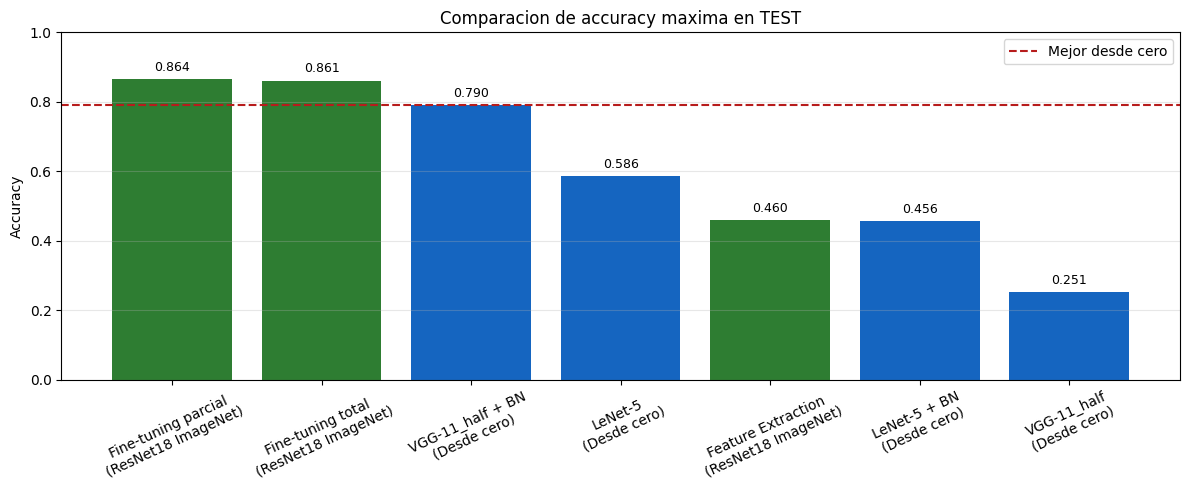

In [24]:
plot_df = comparison.copy()
plot_df["label"] = plot_df["model"] + "\n(" + plot_df["source"] + ")"
colors = plot_df["source"].map({"ResNet18 ImageNet": "#2E7D32", "Desde cero": "#1565C0"}).fillna("#616161")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot_df["label"], plot_df["best_test_acc"], color=colors)
ax.axhline(float(best_scratch["best_test_acc"]), color="#B71C1C", linestyle="--", linewidth=1.5, label="Mejor desde cero")
ax.set_title("Comparacion de accuracy maxima en TEST")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend()

for i, acc in enumerate(plot_df["best_test_acc"]):
    ax.text(i, acc + 0.015, f"{acc:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "transfer_vs_scratch_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Analisis por clase del mejor modelo transferido

Mejor estrategia transferida: Fine-tuning parcial | accuracy=0.8645
              precision    recall  f1-score   support

  EOSINOPHIL     0.9043    0.8186    0.8593       623
  LYMPHOCYTE     1.0000    0.9887    0.9943       620
    MONOCYTE     1.0000    0.7355    0.8476       620
  NEUTROPHIL     0.6686    0.9151    0.7727       624

    accuracy                         0.8645      2487
   macro avg     0.8932    0.8645    0.8685      2487
weighted avg     0.8929    0.8645    0.8683      2487



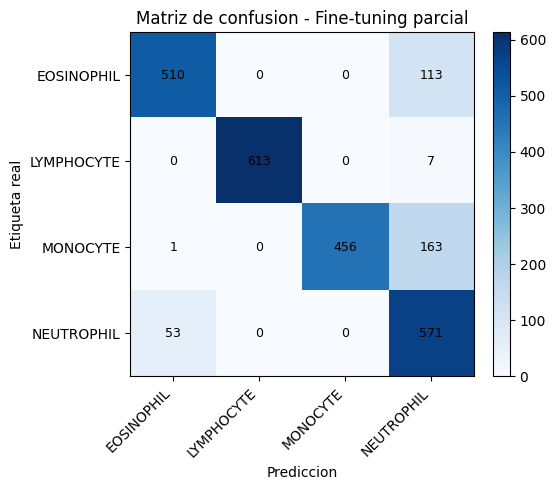

In [25]:
best_transfer_row = transfer_results.iloc[0]
best_transfer_name = best_transfer_row["model"]
best_transfer_run = next(run for run in transfer_runs if run["name"] == best_transfer_name)

metrics = evaluate(best_transfer_run["model"], test_loader, nn.CrossEntropyLoss(), DEVICE, return_predictions=True)
print(f"Mejor estrategia transferida: {best_transfer_name} | accuracy={metrics['acc']:.4f}")

if SKLEARN_AVAILABLE:
    print(classification_report(metrics["targets"], metrics["preds"], target_names=class_names, digits=4))
    cm = confusion_matrix(metrics["targets"], metrics["preds"])
else:
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for target, pred in zip(metrics["targets"], metrics["preds"]):
        cm[target, pred] += 1
    print("sklearn no disponible; se muestra solo matriz de confusion.")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes), class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes), class_names)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Etiqueta real")
ax.set_title(f"Matriz de confusion - {best_transfer_name}")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_transfer_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Conclusion y recomendacion

La recomendacion debe basarse en la tabla `comparison`, pero en un contexto de **datos medicos limitados** normalmente conviene priorizar **fine-tuning parcial**:

- **Feature extraction** entrena muy pocos parametros y reduce el riesgo de sobreajuste, pero puede quedarse corto si las caracteristicas de ImageNet no capturan bien la textura y morfologia de celulas sanguineas.
- **Fine-tuning parcial** conserva filtros tempranos genericos (bordes, color, texturas simples) y adapta los bloques profundos a patrones del dominio medico. Suele dar el mejor balance entre accuracy, estabilidad y riesgo de sobreajuste.
- **Fine-tuning total** puede superar a las otras estrategias si hay suficientes datos, aumentacion y validacion robusta, pero con datos limitados tiene mayor riesgo de olvidar representaciones utiles de ImageNet y ajustar ruido del conjunto de entrenamiento. Por eso se usa un LR muy pequeno.

Decision practica: si `Fine-tuning parcial` queda cerca del mejor accuracy observado, se recomienda como estrategia principal. Si `Feature Extraction` empata o supera al parcial, se prefiere por simplicidad y menor varianza. Si `Fine-tuning total` gana por un margen claro, debe reportarse junto con evidencia adicional de estabilidad por clase, matriz de confusion y, idealmente, validacion cruzada o un conjunto externo.

In [26]:
best_overall = comparison.iloc[0]
best_transfer = transfer_results.iloc[0]
partial_row = transfer_results.loc[transfer_results["model"].eq("Fine-tuning parcial")].iloc[0]

print("Resumen final")
print("- Mejor desde cero:", f"{best_scratch['model']} ({best_scratch['best_test_acc']:.4f})")
print("- Mejor transferencia:", f"{best_transfer['model']} ({best_transfer['best_test_acc']:.4f})")
print("- Mejor global:", f"{best_overall['model']} ({best_overall['source']}, {best_overall['best_test_acc']:.4f})")
print("- Fine-tuning parcial:", f"{partial_row['best_test_acc']:.4f}")

if partial_row["best_test_acc"] >= best_transfer["best_test_acc"] - 0.02:
    recommendation = "Fine-tuning parcial"
elif best_transfer["model"] == "Feature Extraction":
    recommendation = "Feature Extraction"
else:
    recommendation = best_transfer["model"]

print(f"Recomendacion para datos medicos limitados: {recommendation}")

Resumen final
- Mejor desde cero: VGG-11_half + BN (0.7901)
- Mejor transferencia: Fine-tuning parcial (0.8645)
- Mejor global: Fine-tuning parcial (ResNet18 ImageNet, 0.8645)
- Fine-tuning parcial: 0.8645
Recomendacion para datos medicos limitados: Fine-tuning parcial
